<a href="https://colab.research.google.com/github/Yahya1805/machine-learning_2026/blob/main/ML_JS05_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum 1: Klusterisasi Hirarki (HDBSCAN)

Notebook ini berisi seluruh rangkaian kode untuk praktikum klusterisasi hirarki menggunakan algoritma HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise), lengkap dengan visualisasi serta perbandingannya dengan DBSCAN berdasarkan jobsheet.

In [1]:
!pip install hdbscan

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import hdbscan
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs

In [3]:
def plot(X, labels, probabilities=None, parameters=None, ground_truth=False, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    labels = labels if labels is not None else np.ones(X.shape[0])
    probabilities = probabilities if probabilities is not None else np.ones(X.shape[0])
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    proba_map = {idx: probabilities[idx] for idx in range(len(labels))}

    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = [0, 0, 0, 1]

        class_index = (labels == k).nonzero()[0]
        for ci in class_index:
            ax.plot(
                X[ci, 0],
                X[ci, 1],
                "x" if k == -1 else "o",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=4 if k == -1 else 1 + 5 * proba_map[ci]
            )

    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    preamble = "True" if ground_truth else "Estimated"
    title = f"{preamble} number of clusters: {n_clusters_}"
    if parameters is not None:
        parameters_str = ", ".join(f"{k}={v}" for k, v in parameters.items())
        title += f" | {parameters_str}"
    ax.set_title(title)
    plt.tight_layout()

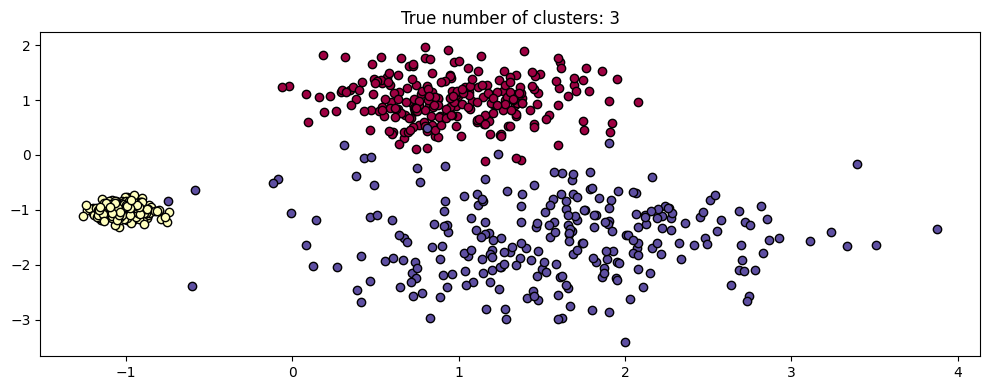

In [4]:
centers = [[1, 1], [-1, -1], [1.5, -1.5]]
X, y = make_blobs(n_samples=750, centers=centers, cluster_std=[0.4, 0.1, 0.75], random_state=0)

# Tampilkan ground truth
plot(X, y, ground_truth=True)

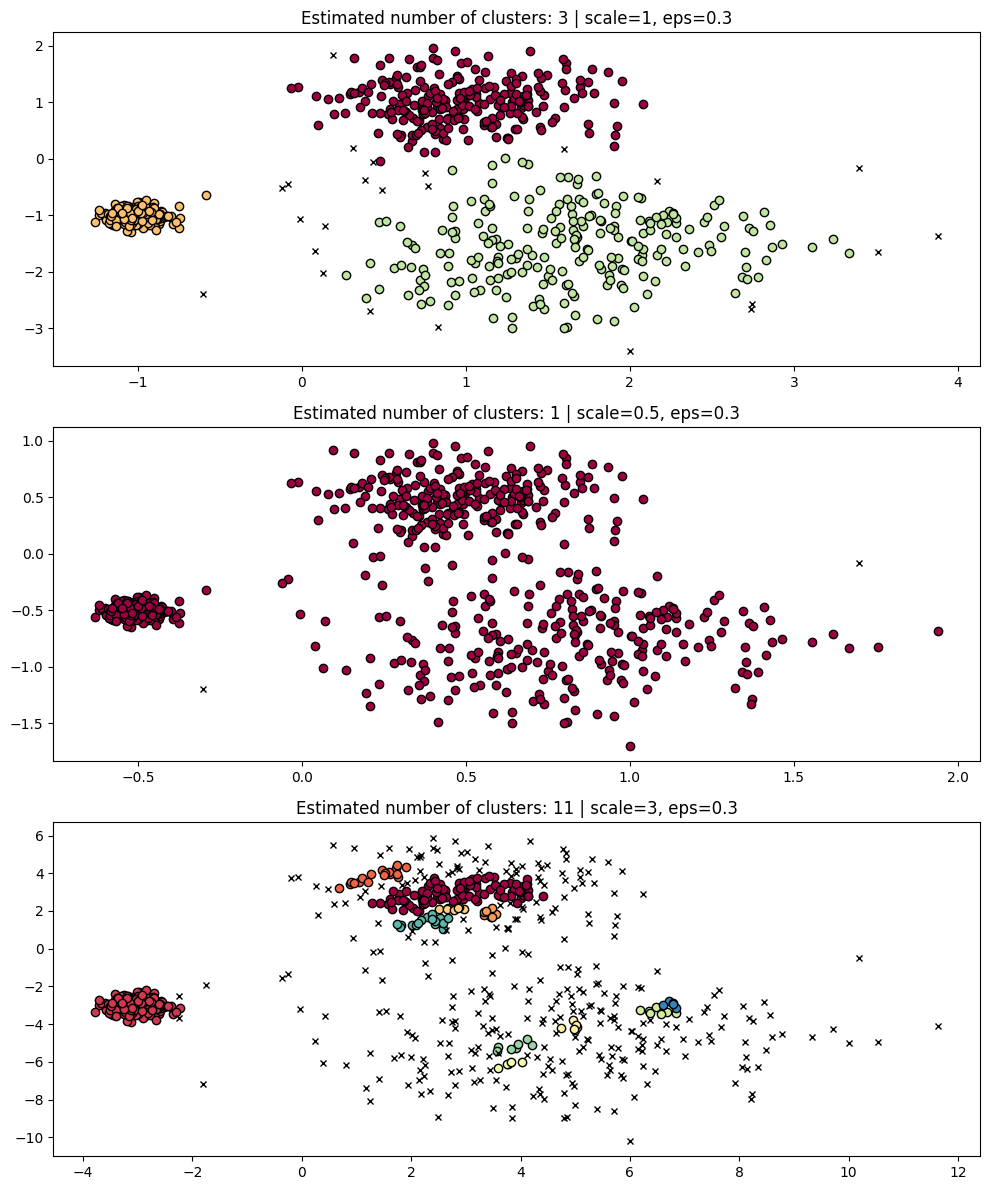

In [5]:
scales = [1, 0.5, 3]
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for i, scale in enumerate(scales):
    scaled_X = scale * X
    db = DBSCAN(eps=0.3).fit(scaled_X)
    plot(scaled_X, db.labels_, parameters={'scale': scale, 'eps': 0.3}, ax=axes[i])

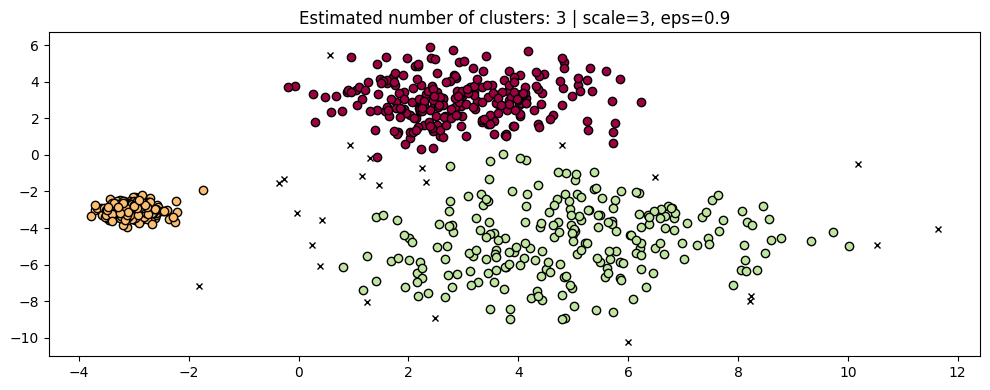

In [6]:
scaled_X_3 = 3 * X
db_corrected = DBSCAN(eps=0.9).fit(scaled_X_3)
plot(scaled_X_3, db_corrected.labels_, parameters={'scale': 3, 'eps': 0.9})

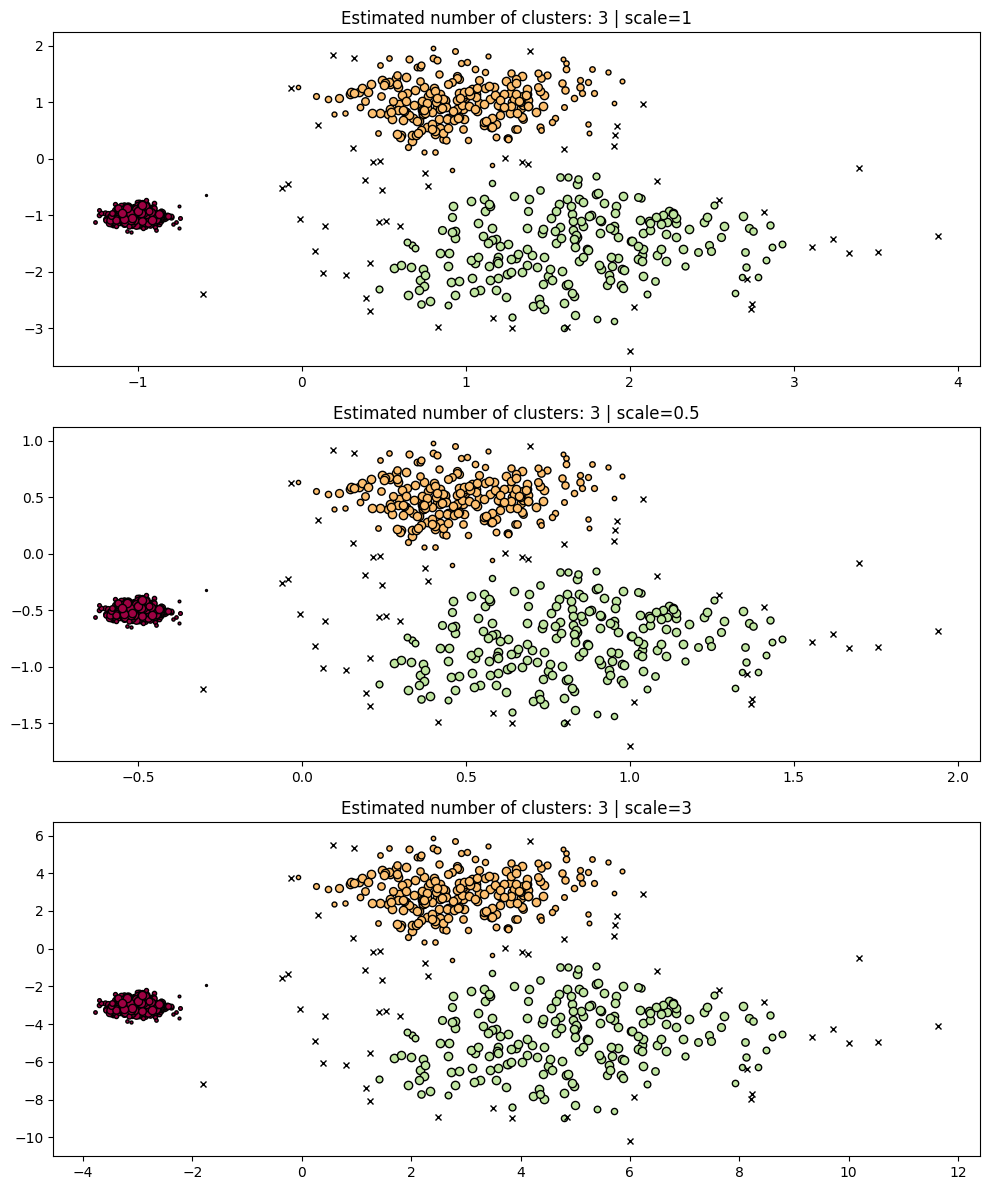

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for i, scale in enumerate(scales):
    scaled_X = scale * X
    hdb = hdbscan.HDBSCAN().fit(scaled_X)
    plot(scaled_X, hdb.labels_, probabilities=hdb.probabilities_, parameters={'scale': scale}, ax=axes[i])

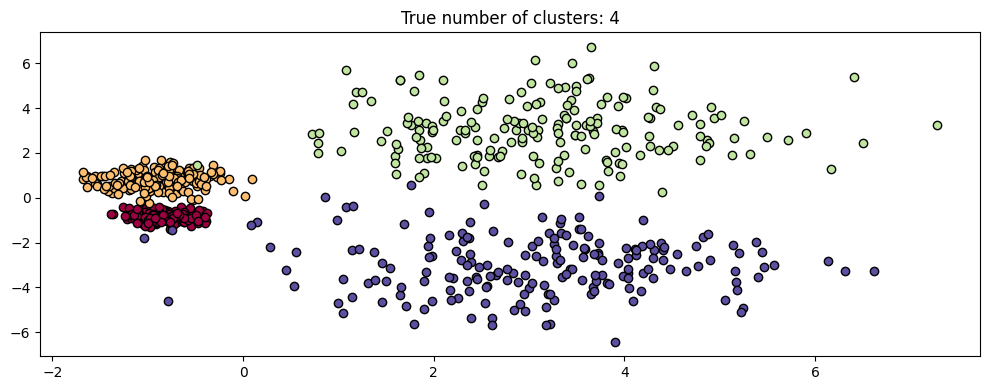

In [8]:
centers2 = [[-0.85, -0.85], [-0.85, 0.85], [3, 3], [3, -3]]
X2, y2 = make_blobs(n_samples=750, centers=centers2, cluster_std=[0.2, 0.35, 1.35, 1.35], random_state=0)

# Tampilkan ground truth dataset kedua
plot(X2, y2, ground_truth=True)

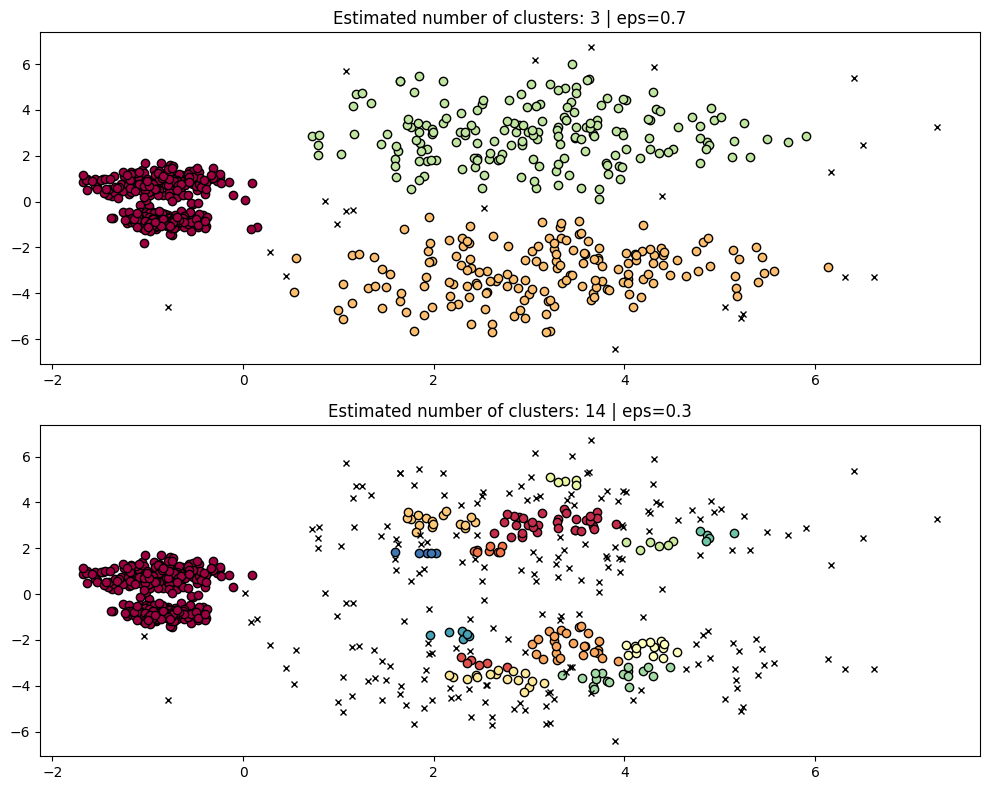

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# DBSCAN eps=0.7
db_07 = DBSCAN(eps=0.7).fit(X2)
plot(X2, db_07.labels_, parameters={'eps': 0.7}, ax=axes[0])

# DBSCAN eps=0.3
db_03 = DBSCAN(eps=0.3).fit(X2)
plot(X2, db_03.labels_, parameters={'eps': 0.3}, ax=axes[1])

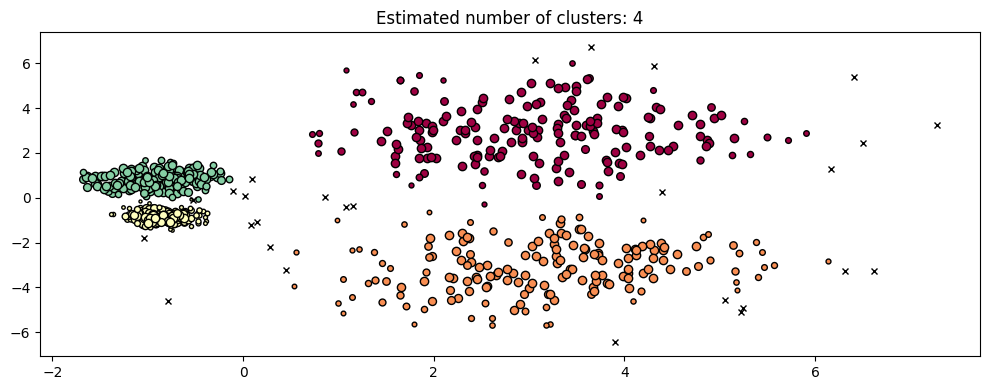

In [10]:
hdb_multi = hdbscan.HDBSCAN().fit(X2)
plot(X2, hdb_multi.labels_, probabilities=hdb_multi.probabilities_)

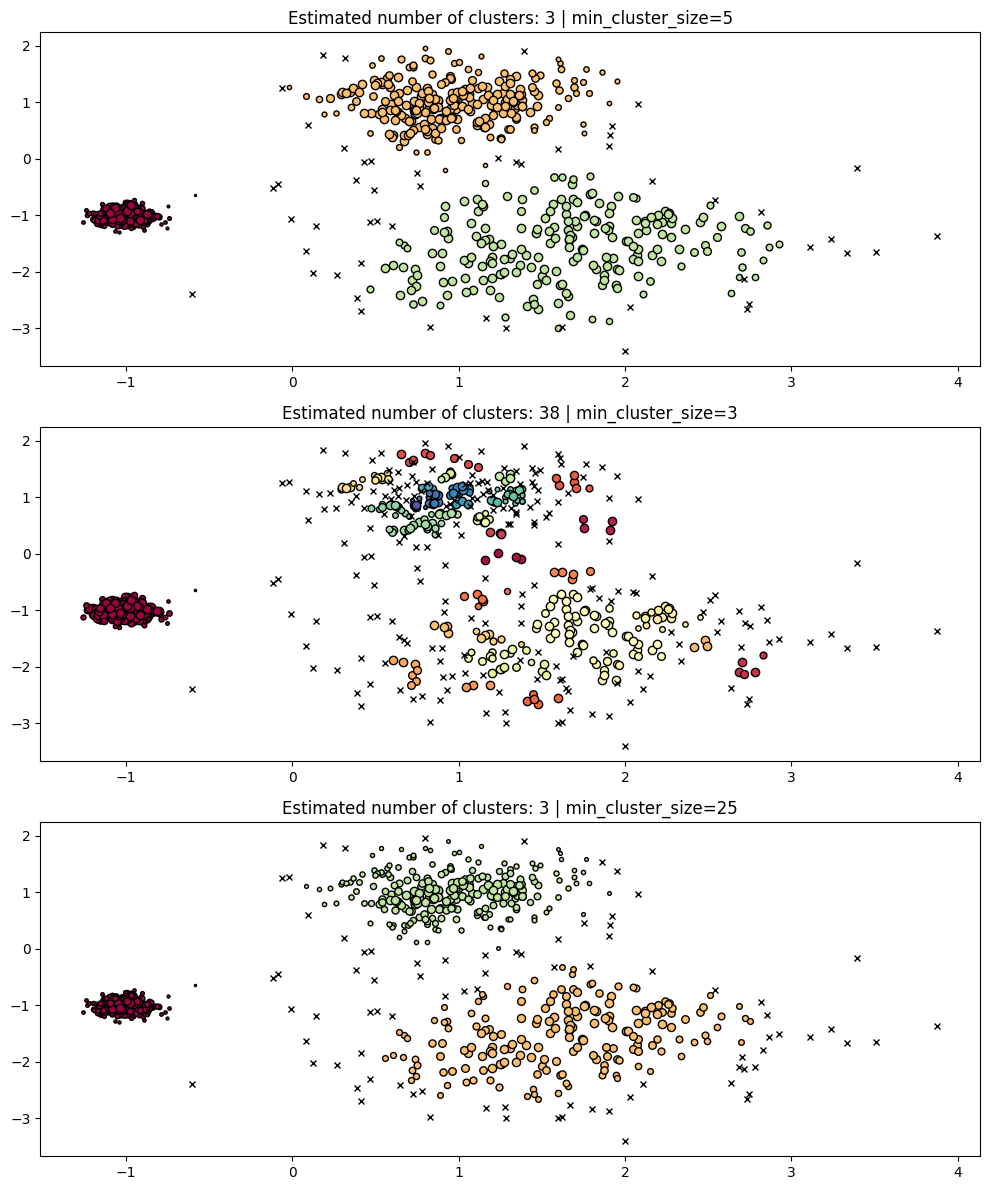

In [11]:
min_cluster_sizes = [5, 3, 25]
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for i, mcs in enumerate(min_cluster_sizes):
    hdb = hdbscan.HDBSCAN(min_cluster_size=mcs).fit(X)
    plot(X, hdb.labels_, probabilities=hdb.probabilities_, parameters={"min_cluster_size": mcs}, ax=axes[i])

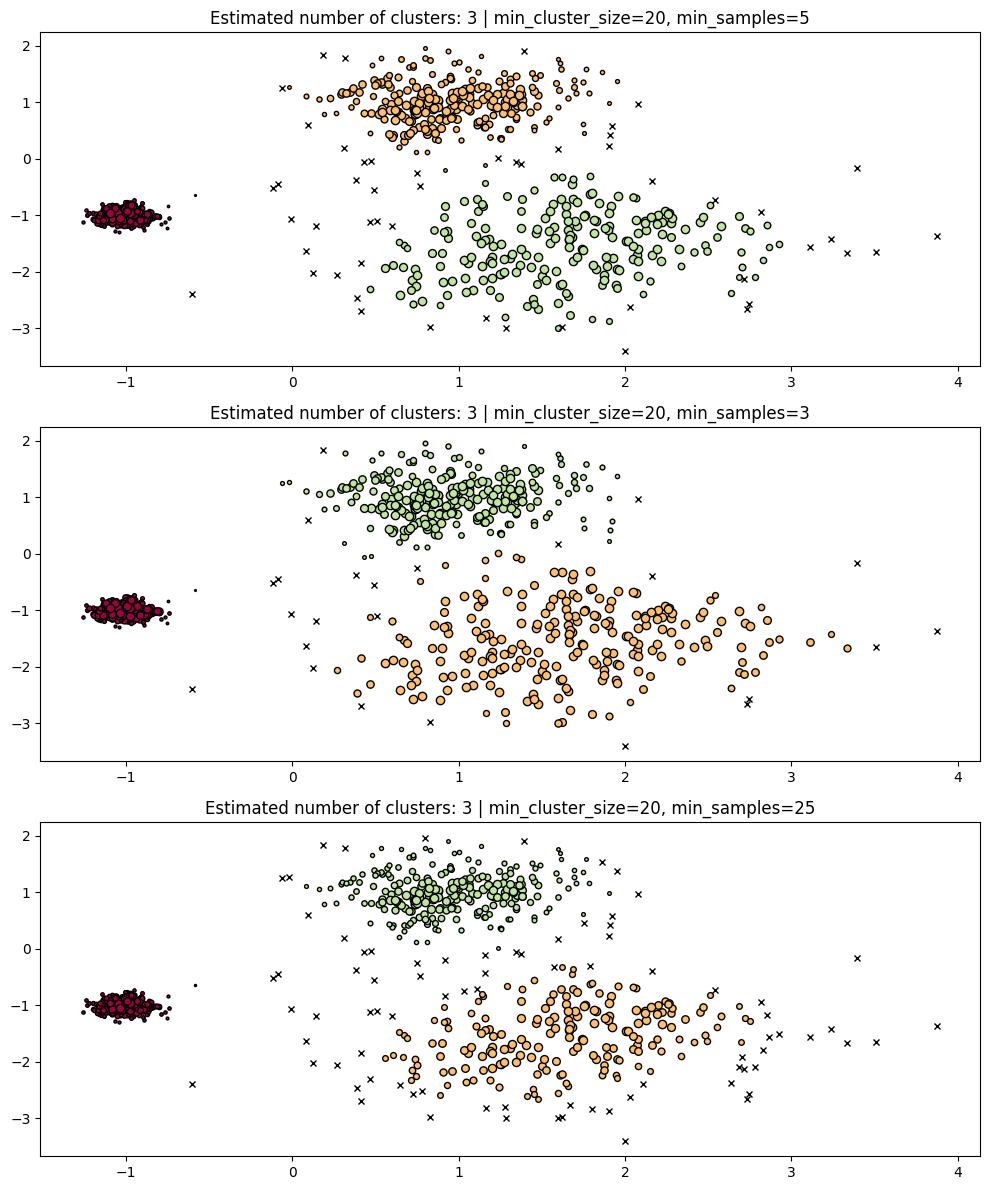

In [12]:
min_samples_experiments = [
    {"min_cluster_size": 20, "min_samples": 5},
    {"min_cluster_size": 20, "min_samples": 3},
    {"min_cluster_size": 20, "min_samples": 25}
]

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for i, params in enumerate(min_samples_experiments):
    hdb = hdbscan.HDBSCAN(**params).fit(X)
    plot(X, hdb.labels_, probabilities=hdb.probabilities_, parameters=params, ax=axes[i])

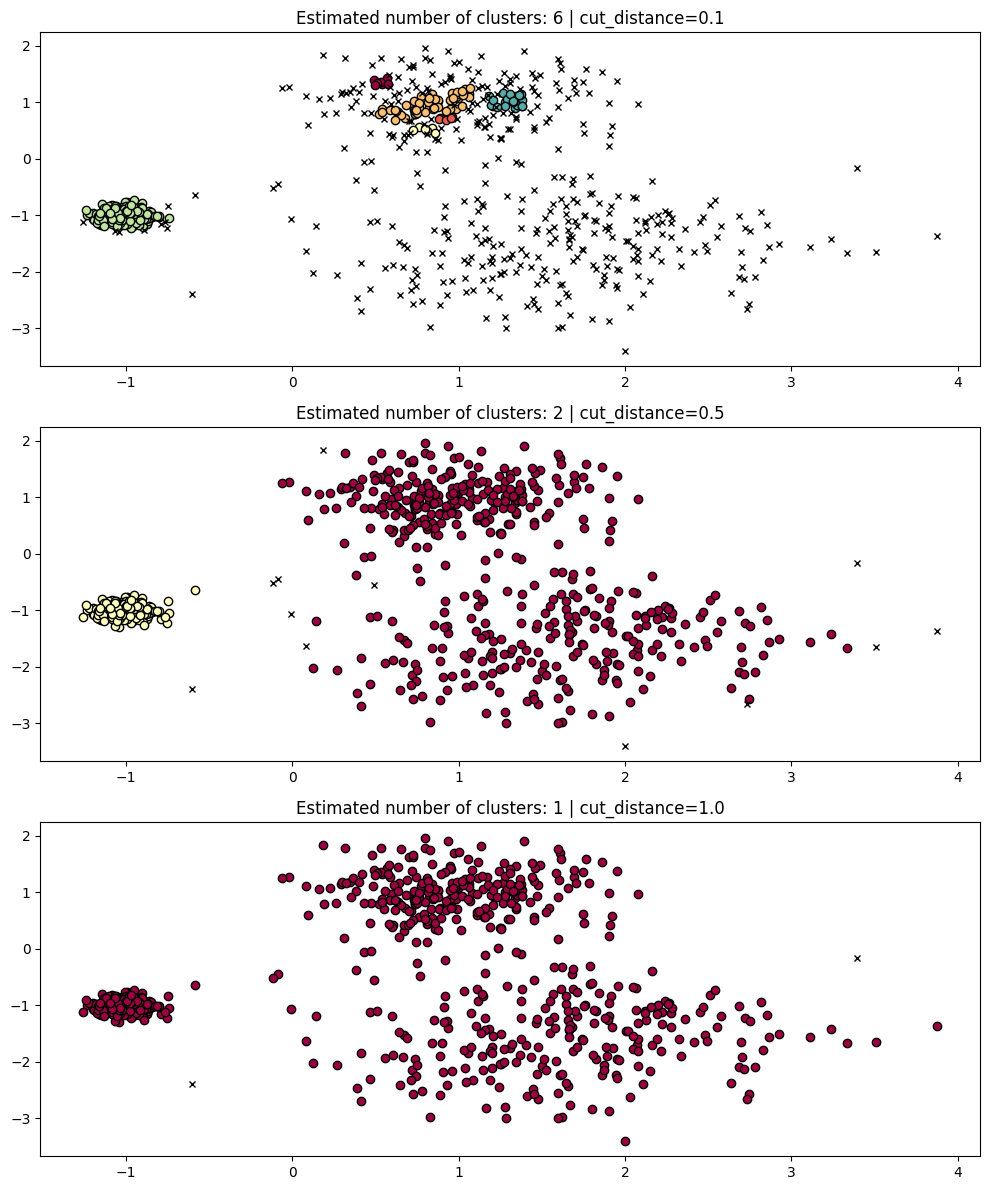

In [13]:
hdb = hdbscan.HDBSCAN().fit(X)
cut_distances = [0.1, 0.5, 1.0]

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for i, cut_dist in enumerate(cut_distances):
    labels = hdb.dbscan_clustering(cut_distance=cut_dist)
    plot(X, labels, parameters={"cut_distance": cut_dist}, ax=axes[i])

In [14]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Menggunakan model HDBSCAN default
hdb_eval = hdbscan.HDBSCAN().fit(X)

# Menghitung skor evaluasi
sil_score = silhouette_score(X, hdb_eval.labels_)
dbi_score = davies_bouldin_score(X, hdb_eval.labels_)

print(f"Silhouette Score: {sil_score:.4f}")
print(f"Davies-Bouldin Index: {dbi_score:.4f}")

Silhouette Score: 0.6451
Davies-Bouldin Index: 2.1284


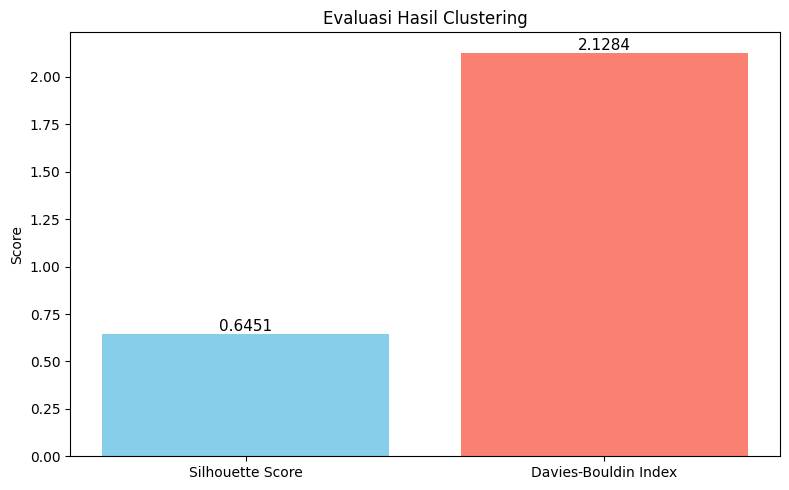

In [15]:
scores = {"Silhouette Score": sil_score, "Davies-Bouldin Index": dbi_score}

# Visualisasi evaluasi dengan bar chart
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(scores.keys(), scores.values(), color=['skyblue', 'salmon'])
ax.set_ylabel("Score")
ax.set_title("Evaluasi Hasil Clustering")

# Menambahkan nilai di atas bar
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.4f}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

### Penjelasan Evaluasi:
- **Silhouette Score**: Nilainya berkisar antara -1 hingga 1. Nilai yang mendekati 1 atau lebih tinggi menunjukkan kualitas clustering yang lebih baik karena titik-titik dalam kluster berdekatan satu sama lain dan berjauhan dari kluster lain.
- **Davies-Bouldin Index**: Nilainya bernilai non-negatif. Nilai yang lebih rendah menunjukkan clustering yang lebih baik karena menunjukkan bahwa kluster-kluster terpisah dengan baik dan padat di dalamnya.